<a href="https://www.kaggle.com/code/sonawanelalitsunil/retail-price-trends-2017-2025-ml-100?scriptVersionId=233150375" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/product-retail-price-survey-2017-2025/Retail_Prices_of _Products_dashboard.pbix
/kaggle/input/product-retail-price-survey-2017-2025/Retail_Prices_of _Products.csv
/kaggle/input/product-retail-price-survey-2017-2025/Data_Dictionary.txt


## Title: Retail Price Trends (2017–2025)

### Description: A survey analyzing product retail price changes and market trends over the years 2017 to 2025.










## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/product-retail-price-survey-2017-2025/Retail_Prices_of _Products.csv')

In [3]:
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars


In [4]:
df.tail()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM
118477,2025,February,Province 11,Nuts & Snacks,"Sunflower seeds, 400 grams",4.50,No,12.0,4.50,Non-Essential,10.109,Dollars
118478,2025,February,Province 11,Toiletries & Cleaning,"Deodorant, 85 grams",8.07,Yes,12.0,9.04,Essential,10.750,Dollars
118479,2025,February,Province 11,Toiletries & Cleaning,"Toothpaste, 100 millilitres",4.13,Yes,12.0,4.63,Essential,10.760,Dollars
118480,2025,February,Province 11,Toiletries & Cleaning,"Shampoo, 400 millilitres",7.18,Yes,12.0,8.04,Essential,10.770,Dollars
118481,2025,February,Province 11,Toiletries & Cleaning,"Laundry detergent, 4.43 litres",13.19,Yes,12.0,14.77,Essential,10.110,Dollars


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Year              118482 non-null  int64  
 1   Month             118482 non-null  object 
 2   GEO               118482 non-null  object 
 3   Product Category  118482 non-null  object 
 4   Products          118482 non-null  object 
 5   VALUE             118482 non-null  float64
 6   Taxable           118482 non-null  object 
 7   Total tax rate    118482 non-null  float64
 8   Value after tax   118482 non-null  float64
 9   Essential         118482 non-null  object 
 10  COORDINATE        118482 non-null  float64
 11  UOM               118482 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 10.8+ MB


In [6]:
df.describe()

,Year,VALUE,Total tax rate,Value after tax,COORDINATE
count,118482.000000,118482.000000,118482.000000,118482.000000,118482.000000
mean,2020.591837,5.437324,12.632134,5.515499,6.501741
std,2.355363,5.192748,2.899124,5.215311,3.172173
min,2017.000000,0.300000,5.000000,0.300000,1.100000
25%,2019.000000,2.850000,11.000000,2.910000,3.750000
50%,2021.000000,3.990000,13.000000,4.050000,6.500000
75%,2023.000000,5.810000,15.000000,5.947500,9.240000
max,2025.000000,48.450000,15.000000,48.450000,11.990000


In [7]:
df.isnull().sum()

Year                0
Month               0
GEO                 0
Product Category    0
Products            0
VALUE               0
Taxable             0
Total tax rate      0
Value after tax     0
Essential           0
COORDINATE          0
UOM                 0
dtype: int64

In [8]:
df.isnull().sum().sum()

0

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Year                  int64
Month                object
GEO                  object
Product Category     object
Products             object
VALUE               float64
Taxable              object
Total tax rate      float64
Value after tax     float64
Essential            object
COORDINATE          float64
UOM                  object
dtype: object

In [11]:
df.shape

(118482, 12)

In [12]:
df.columns

Index(['Year', 'Month', 'GEO', 'Product Category', 'Products', 'VALUE',
       'Taxable', 'Total tax rate', 'Value after tax', 'Essential',
       'COORDINATE', 'UOM'],
      dtype='object')

## Data visualizations

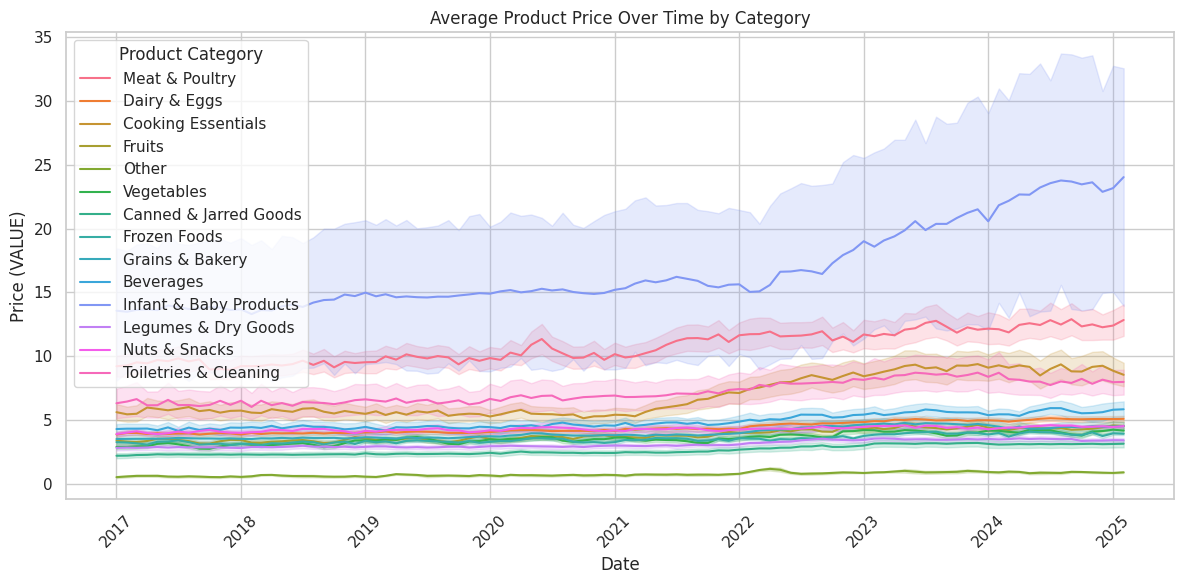

In [13]:
# Combine year and month for time-based plots
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))

# Set visual style
sns.set(style="whitegrid", palette="muted")

# 1. Price Trend Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='VALUE', hue='Product Category', estimator='mean')
plt.title('Average Product Price Over Time by Category')
plt.xlabel('Date')
plt.ylabel('Price (VALUE)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


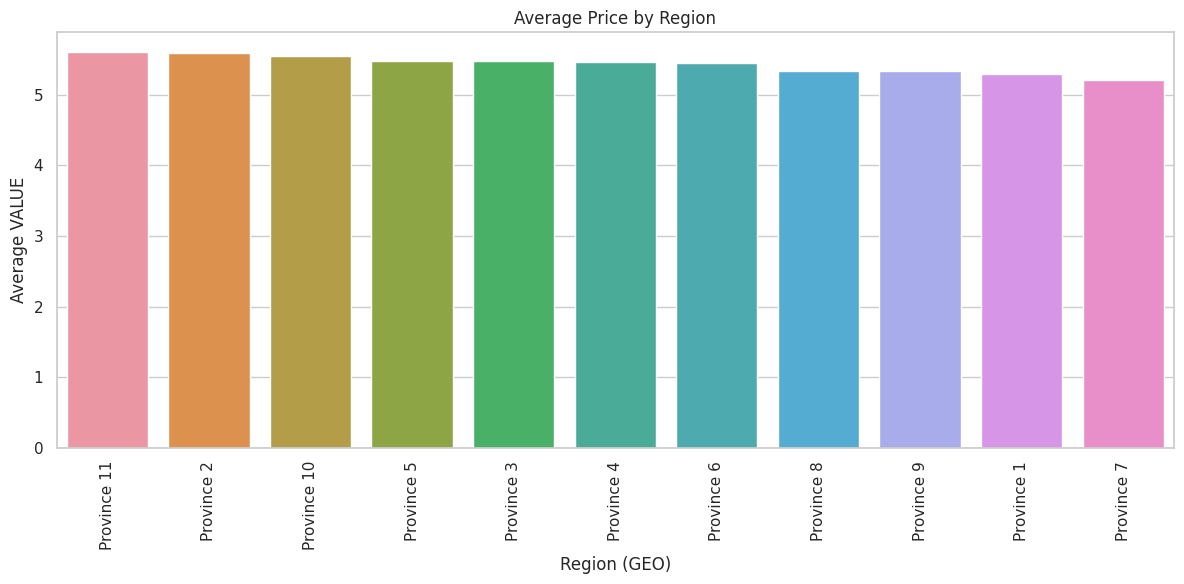

In [14]:
# 2. Regional Price Comparison
plt.figure(figsize=(12, 6))
region_avg = df.groupby('GEO')['VALUE'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values)
plt.title('Average Price by Region')
plt.ylabel('Average VALUE')
plt.xlabel('Region (GEO)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


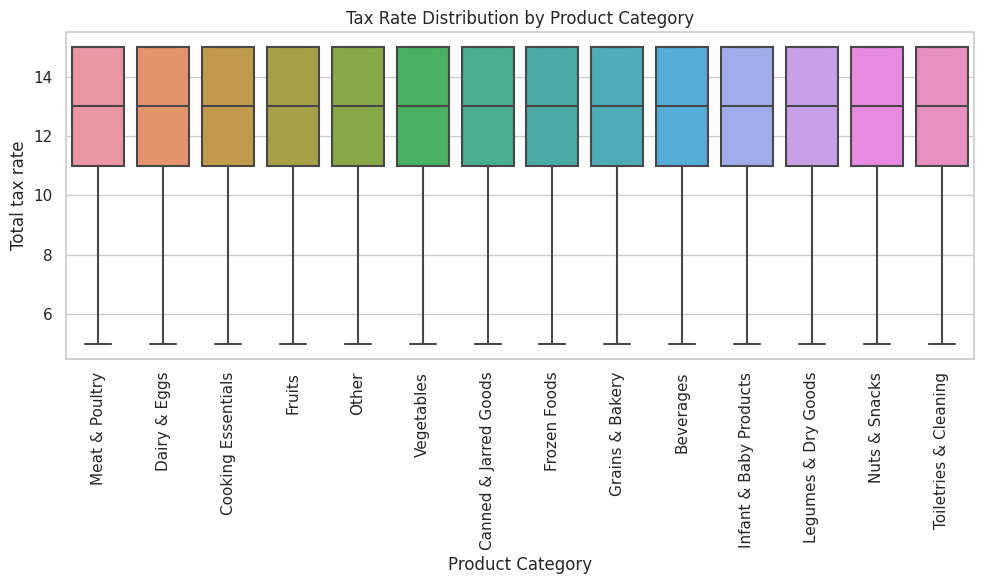

In [15]:
# 3. Tax Rate Distribution by Product Category
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product Category', y='Total tax rate')
plt.title('Tax Rate Distribution by Product Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

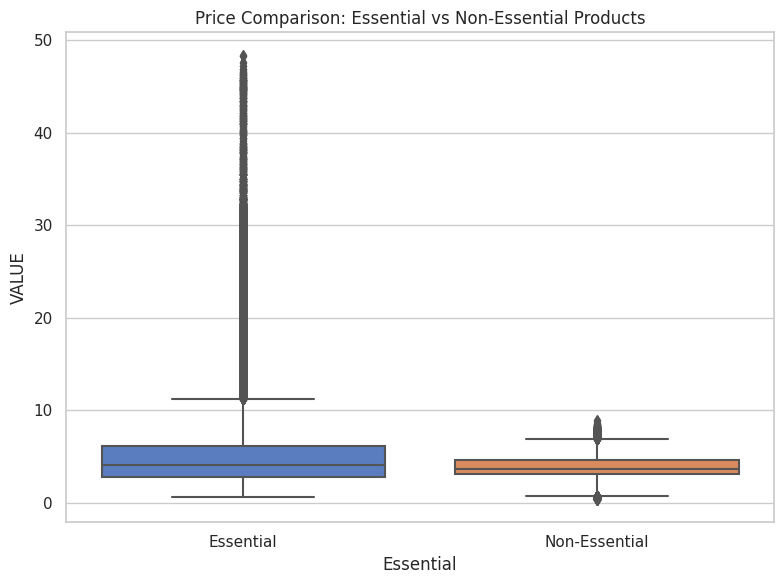

In [16]:
# 4. Essential vs Non-Essential Product Prices
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Essential', y='VALUE')
plt.title('Price Comparison: Essential vs Non-Essential Products')
plt.tight_layout()
plt.show()

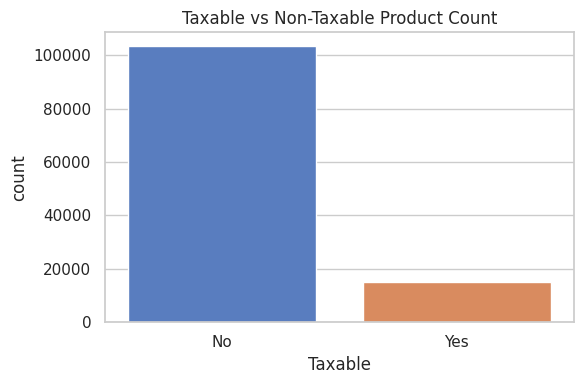

In [17]:
# 5. Taxable Products Count
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Taxable')
plt.title('Taxable vs Non-Taxable Product Count')
plt.tight_layout()
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [19]:
# Preview
print("Initial shape:", df.shape)
print("Columns:", df.columns)

Initial shape: (118482, 13)
Columns: Index(['Year', 'Month', 'GEO', 'Product Category', 'Products', 'VALUE',
       'Taxable', 'Total tax rate', 'Value after tax', 'Essential',
       'COORDINATE', 'UOM', 'Date'],
      dtype='object')


In [20]:
# Convert any 'Date' columns if necessary
if 'Year' in df.columns and 'Month' in df.columns:
    df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
    df['Year_only'] = df['Date'].dt.year
    df['Month_only'] = df['Date'].dt.month
    df.drop(columns=['Date'], inplace=True)
# Drop rows with missing values
df.dropna(inplace=True)

In [21]:
from sklearn.preprocessing import LabelEncoder

# Encode all categorical object-type columns
label_encoders = {}
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [22]:
# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [23]:
# Define target and features
target_col = 'Taxable'
X = df.drop(columns=[target_col])
y = df[target_col]

In [24]:
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)


In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Define ML models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Naive Bayes': GaussianNB()
}

In [27]:
# Train and evaluate models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)

    results[name] = acc

    print(f"\n{name}")
    print(f"Accuracy: {acc:.2f}%")



Logistic Regression
Accuracy: 99.95%

Decision Tree
Accuracy: 99.99%

Random Forest
Accuracy: 100.00%

Gradient Boosting
Accuracy: 99.99%

K-Nearest Neighbors
Accuracy: 99.58%

Support Vector Machine
Accuracy: 87.21%

Naive Bayes
Accuracy: 80.84%


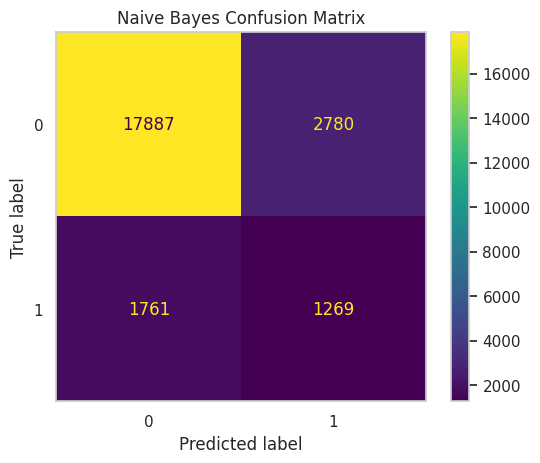

In [28]:
# Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"{name} Confusion Matrix")
plt.grid(False)
plt.show()

In [29]:
# Display accuracy comparison
result_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy (%)': list(results.values())
}).sort_values(by='Accuracy (%)', ascending=False)

print("\n📊 Model Accuracy Comparison:")
print(result_df.to_string(index=False))


📊 Model Accuracy Comparison:
                 Model  Accuracy (%)
         Random Forest     99.995780
         Decision Tree     99.987340
     Gradient Boosting     99.987340
   Logistic Regression     99.945141
   K-Nearest Neighbors     99.582226
Support Vector Machine     87.213571
           Naive Bayes     80.837237


## Thank you...pls upvote!!!!!